# Proof of concept: Adding Spatial Wavelet Decomposition and Reconstruction to Chromatin Deconvolution
February 16, 2024

We've shown that it is possible to decompose a 2D image into wavelet coefficients and reconstruct within cvxpy. The next step is the feasibility with doing a large set of image coefficients and with the chromatin deconvolution. We had previously deconvolved the coefficients of the images, but were unable to enforce valid non-negative coefficients that produce images. So, this may be a chance to find a place where we can enforce valid non-negative f images, because we are now able to reconstruct the images from coefficients within cvxpy to enforce constraints or norms on the minimization function. We will also be checking feasibility and timing of introducing these additional wavelet computations.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
import numpy as np
import pywt

In [3]:
from cc_src.chromatin_model import ChromatinModel
from src.config import load_yl_replicate1_rg1_alpha_vst_config

config = load_yl_replicate1_rg1_alpha_vst_config()
chromatin_model = ChromatinModel(config)
chromatin_model.load_mnase_gene('CLB2', replicate=1)

Loading MNase reads for CLB2...Done.


In [4]:
chromatin_model.create_deconvolution_bins(bin_width=16, bin_height=16,
                                         prom_len=256, gb_len=512)

Unflattened the input data is of shape: (16, 16, 48)
The size of our input data, G is: (16, 768)


Deconvolving gamma prime: 0
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 20 11:51:49 AM: Your problem has 174336 variables, 1 constraints, and 0 parameters.
(CVXPY) Feb 20 11:51:49 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 20 11:51:49 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 20 11:51:49 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 20 11:51:49 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 20 11:51:49 AM: Compiling pr

(CVXPY) Feb 20 11:53:02 AM: 25  5.2e-03  1.0e-02  3.5e-04  3.45e-01   4.919286335e+03   4.919290036e+03   5.2e-03  26.49 
(CVXPY) Feb 20 11:53:02 AM: 26  4.2e-03  8.3e-03  2.7e-04  3.38e-01   4.900773920e+03   4.900777140e+03   4.2e-03  26.82 
(CVXPY) Feb 20 11:53:02 AM: 27  3.6e-03  7.3e-03  2.3e-04  3.36e-01   4.888967458e+03   4.888970406e+03   3.6e-03  27.15 
(CVXPY) Feb 20 11:53:03 AM: 28  3.4e-03  6.8e-03  2.1e-04  3.38e-01   4.882884549e+03   4.882887366e+03   3.4e-03  27.49 
(CVXPY) Feb 20 11:53:03 AM: 29  2.9e-03  5.7e-03  1.7e-04  3.37e-01   4.869015604e+03   4.869018134e+03   2.9e-03  27.82 
(CVXPY) Feb 20 11:53:03 AM: 30  2.4e-03  4.7e-03  1.4e-04  3.45e-01   4.852677164e+03   4.852679382e+03   2.4e-03  28.16 
(CVXPY) Feb 20 11:53:04 AM: 31  2.1e-03  4.2e-03  1.2e-04  3.62e-01   4.842859595e+03   4.842861639e+03   2.1e-03  28.51 
(CVXPY) Feb 20 11:53:04 AM: 32  1.3e-03  2.6e-03  6.6e-05  3.73e-01   4.805799492e+03   4.805800919e+03   1.3e-03  29.11 
(CVXPY) Feb 20 11:53:05 

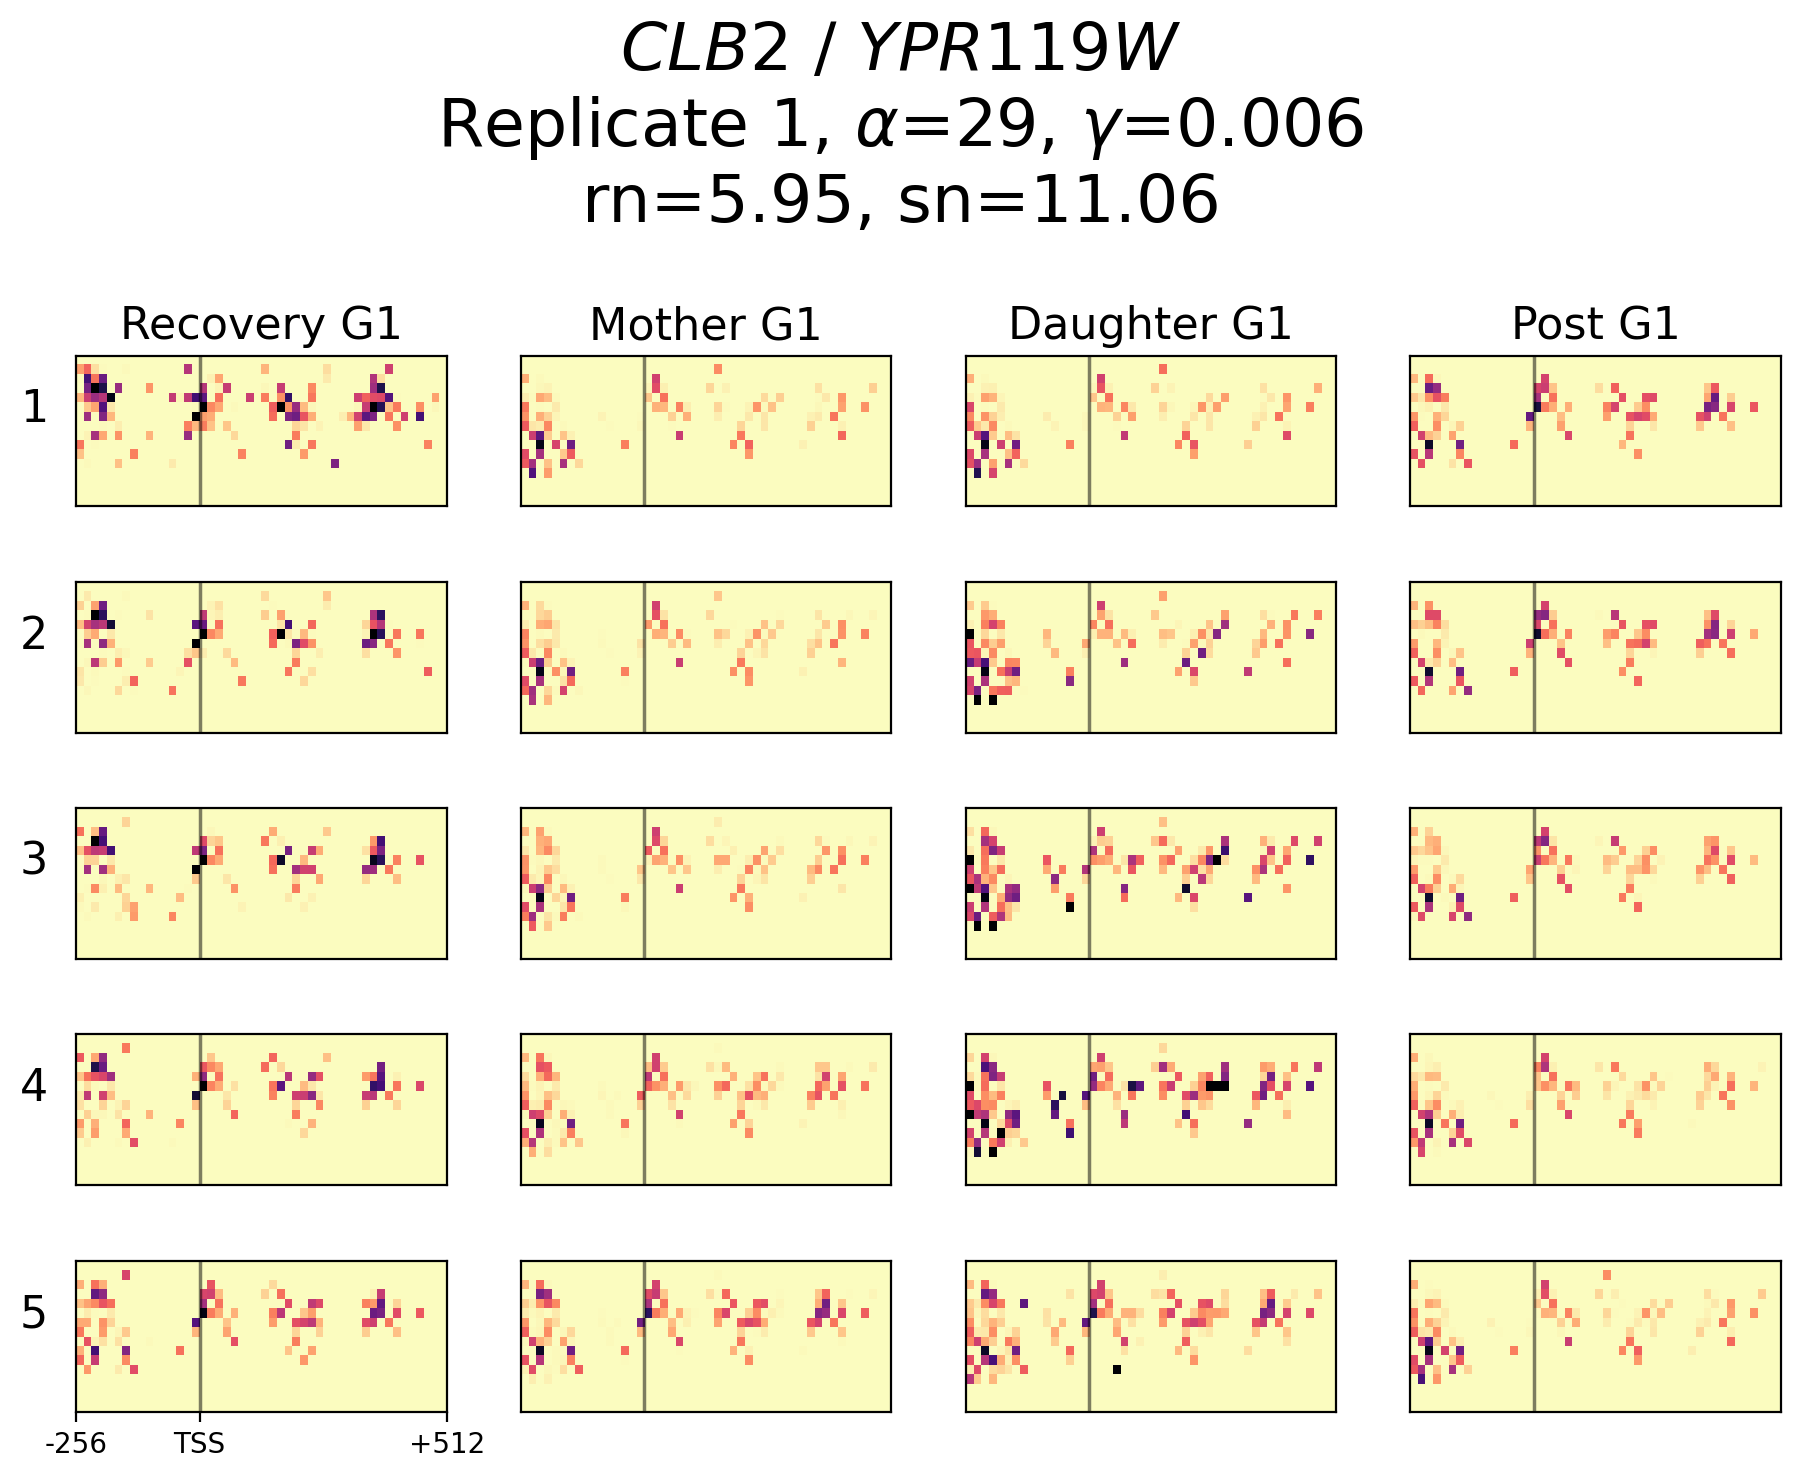

In [8]:
#for gamma_prime in primes:
gamma_prime = 0.001

print(f"Deconvolving gamma prime: {gamma_prime}")
chromatin_model.gamma = 0.006
chromatin_model.deconvolve(verbose=True, gamma_prime=gamma_prime)
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmax=10)

print(chromatin_model.spat_smooth)
plt.savefig(f'output/clb2_spatial_{gamma_prime}.png', dpi=200)


In [ ]:
#for gamma_prime in primes:
gamma_prime = 0.001

print(f"Deconvolving gamma prime: {gamma_prime}")
chromatin_model.gamma = 0.006
chromatin_model.deconvolve(verbose=True, gamma_prime=gamma_prime)
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(vmax=10)

print(chromatin_model.spat_smooth)
plt.savefig(f'output/clb2_spatial_{gamma_prime}.png', dpi=200)


Deconvolving gamma prime: 0.001
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Feb 20 11:53:12 AM: Your problem has 174336 variables, 5 constraints, and 0 parameters.
(CVXPY) Feb 20 11:53:12 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Feb 20 11:53:12 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Feb 20 11:53:12 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Feb 20 11:53:12 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Feb 20 11:53:12 AM: Compilin